In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
print("All imports successful ✓")

All imports successful ✓


In [5]:
df = pd.read_csv("data/etrain_delays.csv")

print("Shape:", df.shape)
print("\nNull values:\n", df.isnull().sum())
print("\nBasic stats:")
df[["average_delay_minutes", "pct_right_time",
    "pct_slight_delay", "pct_significant_delay"]].describe()

Shape: (1900, 11)

Null values:
 train_number               0
train_name                 0
station_code               0
station_name               0
average_delay_minutes    236
pct_right_time             0
pct_slight_delay           0
pct_significant_delay      0
pct_cancelled_unknown      0
scraped_at                 0
source_url                 0
dtype: int64

Basic stats:


,average_delay_minutes,pct_right_time,pct_slight_delay,pct_significant_delay
count,1664.000000,1900.000000,1900.000000,1900.000000
mean,40.699519,50.411721,32.965258,15.448874
std,50.337954,33.082810,25.783788,22.303999
min,0.000000,0.000000,0.000000,0.000000
25%,13.000000,17.680000,11.110000,0.000000
50%,24.000000,53.330000,28.000000,6.560000
75%,49.000000,80.000000,50.237500,20.000000
max,586.000000,100.000000,100.000000,100.000000


In [6]:
# Drop rows with missing target
df = df.dropna(subset=["average_delay_minutes"])

# Remove rows where delay is negative (data errors)
df = df[df["average_delay_minutes"] >= 0]

# Drop columns not useful for modelling
df = df.drop(columns=["scraped_at", "source_url"])

# Fill any remaining nulls in percentage columns with 0
pct_cols = ["pct_right_time", "pct_slight_delay",
            "pct_significant_delay", "pct_cancelled_unknown"]
df[pct_cols] = df[pct_cols].fillna(0)

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (1664, 9)


,train_number,train_name,station_code,station_name,average_delay_minutes,pct_right_time,pct_slight_delay,pct_significant_delay,pct_cancelled_unknown
0,12673,Cheran Express,MAS,CHENNAI CENTRAL,2.0,98.90,0.27,0.00,0.83
1,12673,Cheran Express,AVD,AVADI,0.0,0.27,0.00,0.00,99.73
2,12673,Cheran Express,AJJ,ARAKKONAM,16.0,55.34,44.38,0.27,0.01
3,12673,Cheran Express,KPD,KATPADI JN,17.0,48.49,49.86,1.64,0.01
5,12673,Cheran Express,SA,SALEM JN,25.0,23.01,74.79,2.19,0.01


In [7]:
le_station = LabelEncoder()
le_train   = LabelEncoder()

df["station_enc"] = le_station.fit_transform(df["station_code"].astype(str))
df["train_enc"]   = le_train.fit_transform(df["train_number"].astype(str))

# Derived feature: unreliability score
# High significant delay % + high cancellation % = high risk station
df["unreliability_score"] = (
    df["pct_significant_delay"] * 2 +
    df["pct_cancelled_unknown"] * 1.5
)

print("New columns added: station_enc, train_enc, unreliability_score")
df[["station_code", "station_enc", "unreliability_score",
    "average_delay_minutes"]].head(8)

New columns added: station_enc, train_enc, unreliability_score


,station_code,station_enc,unreliability_score,average_delay_minutes
0,MAS,266,1.245,2.0
1,AVD,28,149.595,0.0
2,AJJ,12,0.555,16.0
3,KPD,228,3.295,17.0
5,SA,384,4.395,25.0
6,ED,142,4.380,25.0
7,TUP,451,3.840,24.0
8,CBF,93,1.655,13.0


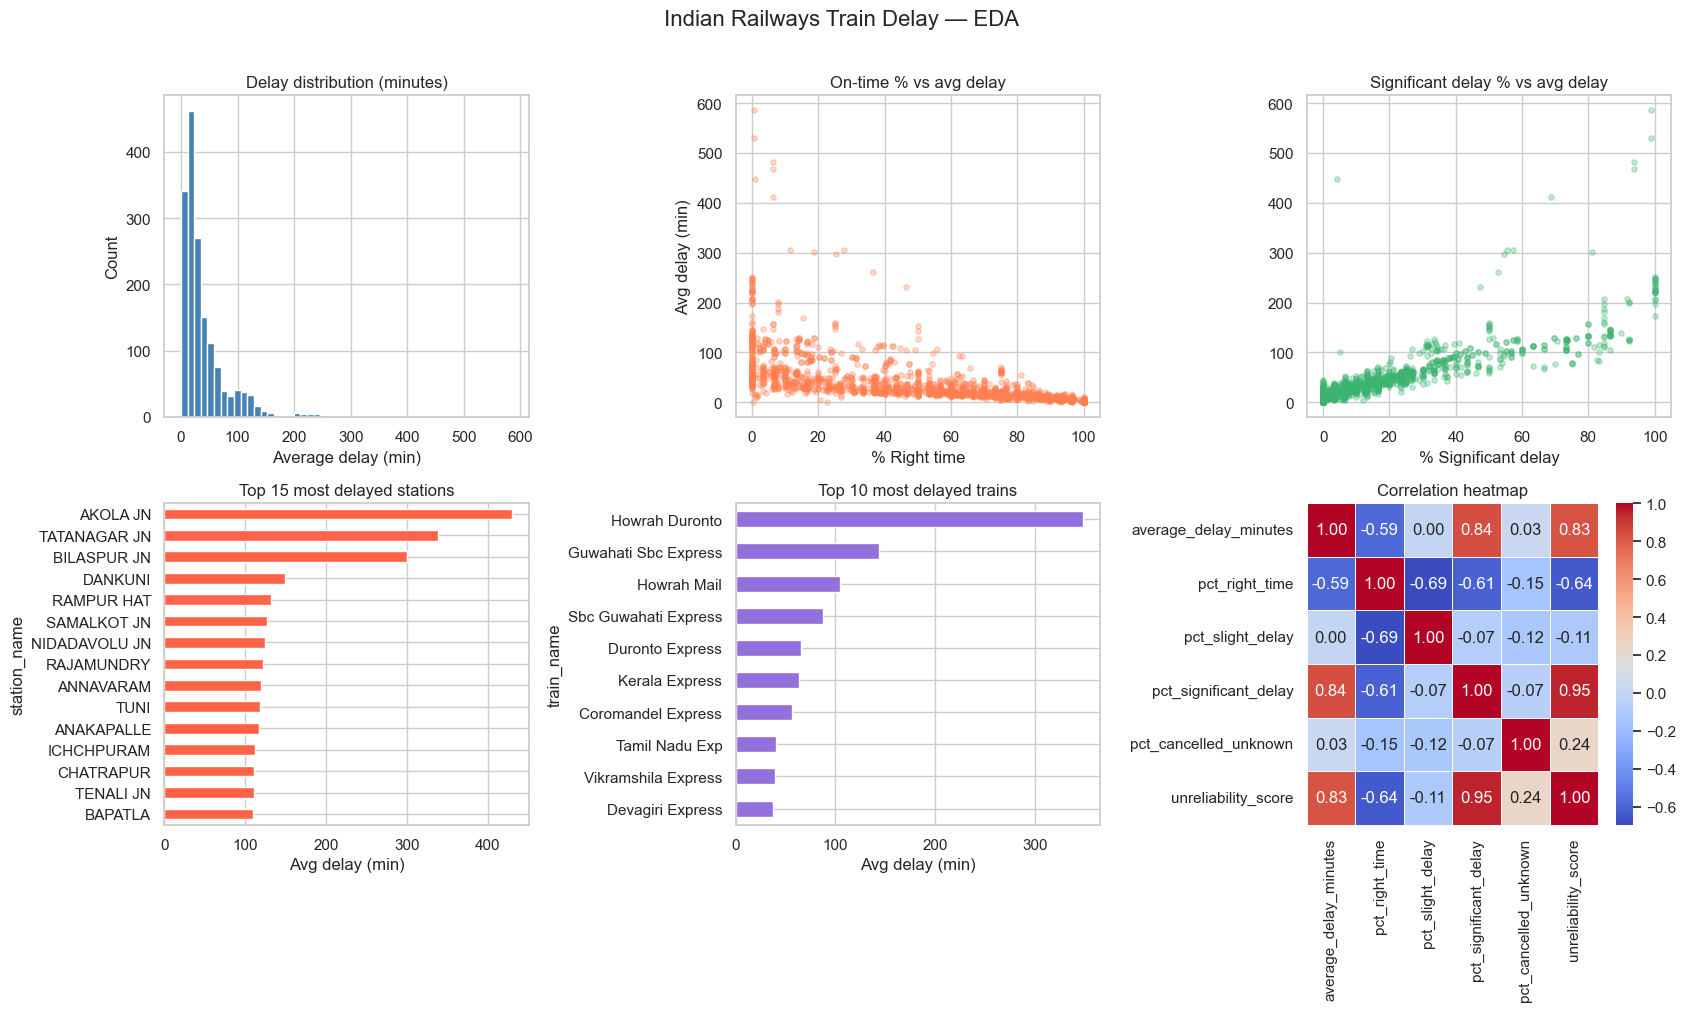

Saved: eda_plots.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Indian Railways Train Delay — EDA", fontsize=16, y=1.01)

# Plot 1: Target distribution
axes[0,0].hist(df["average_delay_minutes"], bins=50,
               color="steelblue", edgecolor="white")
axes[0,0].set_title("Delay distribution (minutes)")
axes[0,0].set_xlabel("Average delay (min)")
axes[0,0].set_ylabel("Count")

# Plot 2: % Right time vs delay scatter
axes[0,1].scatter(df["pct_right_time"], df["average_delay_minutes"],
                  alpha=0.3, color="coral", s=15)
axes[0,1].set_title("On-time % vs avg delay")
axes[0,1].set_xlabel("% Right time")
axes[0,1].set_ylabel("Avg delay (min)")

# Plot 3: % Significant delay vs avg delay
axes[0,2].scatter(df["pct_significant_delay"], df["average_delay_minutes"],
                  alpha=0.3, color="mediumseagreen", s=15)
axes[0,2].set_title("Significant delay % vs avg delay")
axes[0,2].set_xlabel("% Significant delay")

# Plot 4: Top 15 most delayed stations
top_stations = (df.groupby("station_name")["average_delay_minutes"]
                  .mean()
                  .nlargest(15)
                  .sort_values())
top_stations.plot(kind="barh", ax=axes[1,0], color="tomato")
axes[1,0].set_title("Top 15 most delayed stations")
axes[1,0].set_xlabel("Avg delay (min)")

# Plot 5: Top 10 most delayed trains
top_trains = (df.groupby("train_name")["average_delay_minutes"]
                .mean()
                .nlargest(10)
                .sort_values())
top_trains.plot(kind="barh", ax=axes[1,1], color="mediumpurple")
axes[1,1].set_title("Top 10 most delayed trains")
axes[1,1].set_xlabel("Avg delay (min)")

# Plot 6: Correlation heatmap
num_cols = ["average_delay_minutes", "pct_right_time",
            "pct_slight_delay", "pct_significant_delay",
            "pct_cancelled_unknown", "unreliability_score"]
corr = df[num_cols].corr()
sns.heatmap(corr, ax=axes[1,2], annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, cbar=True)
axes[1,2].set_title("Correlation heatmap")

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_plots.png")

In [9]:
feature_cols = [
    "station_enc",
    "train_enc",
    "pct_right_time",
    "pct_slight_delay",
    "pct_significant_delay",
    "pct_cancelled_unknown",
    "unreliability_score"
]

X = df[feature_cols]
y = df["average_delay_minutes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features used    : {feature_cols}")
print("Model trained ✓")

Training samples : 1331
Test samples     : 333
Features used    : ['station_enc', 'train_enc', 'pct_right_time', 'pct_slight_delay', 'pct_significant_delay', 'pct_cancelled_unknown', 'unreliability_score']
Model trained ✓


Mean Absolute Error : 6.05 minutes
R² Score            : 0.941


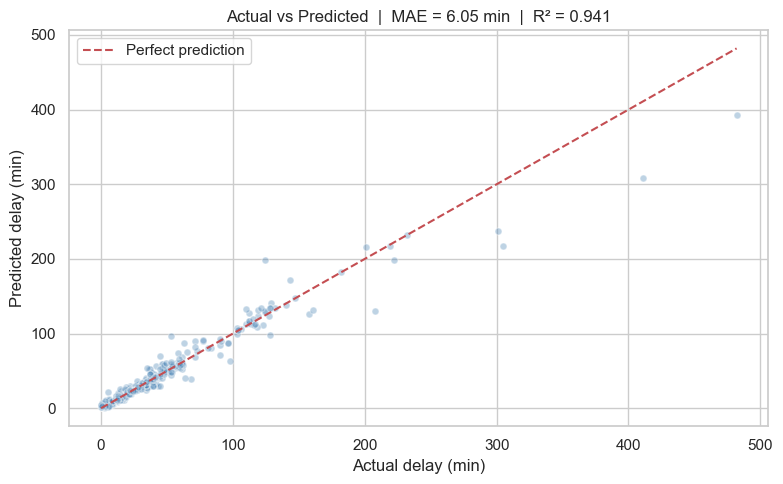

Saved: model_results.png


In [10]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Mean Absolute Error : {mae:.2f} minutes")
print(f"R² Score            : {r2:.3f}")

# Actual vs Predicted plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.35, color="steelblue",
            edgecolors="white", s=25)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--", lw=1.5, label="Perfect prediction")
plt.xlabel("Actual delay (min)")
plt.ylabel("Predicted delay (min)")
plt.title(f"Actual vs Predicted  |  MAE = {mae:.2f} min  |  R² = {r2:.3f}")
plt.legend()
plt.tight_layout()
plt.savefig("model_results.png", dpi=150)
plt.show()
print("Saved: model_results.png")

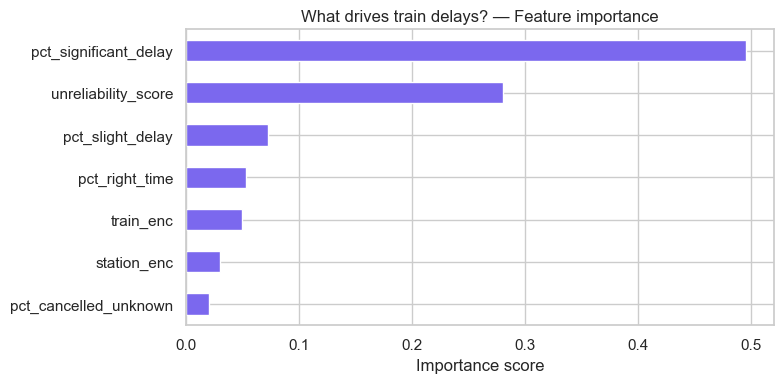

In [11]:
importances = (pd.Series(model.feature_importances_, index=feature_cols)
                 .sort_values(ascending=True))

plt.figure(figsize=(8, 4))
importances.plot(kind="barh", color="mediumslateblue", edgecolor="white")
plt.title("What drives train delays? — Feature importance")
plt.xlabel("Importance score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

In [12]:
# Pick any station from the dataset and predict its delay
sample = X_test.iloc[[0]]
actual    = y_test.iloc[0]
predicted = model.predict(sample)[0]

station = df.iloc[y_test.index[0]]["station_name"]
train   = df.iloc[y_test.index[0]]["train_name"]

print(f"Train   : {train}")
print(f"Station : {station}")
print(f"Actual delay    : {actual:.1f} min")
print(f"Predicted delay : {predicted:.1f} min")
print(f"Error           : {abs(actual - predicted):.1f} min")

Train   : Garib Rath
Station : KANNUR
Actual delay    : 12.0 min
Predicted delay : 8.8 min
Error           : 3.2 min


# Train Delay Prediction — Central Railway

Predicts average train delays at Indian railway stations using historical
on-time performance data and a Random Forest Regressor.

## Results
| Metric | Value |
|--------|-------|
| MAE | 6.05 minutes |
| R² Score | 0.941 |
| Model | Random Forest Regressor (100 trees) |
| Dataset | Indian Railways Train Delays 2025 (Kaggle) |

## Features used
- Station identity, Train identity
- % Right time, % Slight delay, % Significant delay
- % Cancelled/unknown, Unreliability score (engineered)

## How to run
1. Clone this repo
2. Place dataset CSV in `data/etrain_delays.csv`
3. Open `train_delay.ipynb` in Jupyter and run all cells

## Tools
Python · Pandas · Scikit-learn · Matplotlib · Seaborn